### Problem statement:
PeerLoanKart is an NBFC (non-banking financial company) that facilitates peer-to-peer loans. It connects people who need money (borrowers) with people who have money (investors). As an investor, you would want to invest in people who showed a profile of having a high probability of paying you back. Create a model that will help predict whether a borrower will repay the loan.

#### 1) Importing Necessary Libraries:

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('loan_borowwer_data.csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df.shape

(9578, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


In [7]:
df.dtypes

credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

- There are Numeric ane Categorical features in data.
- Data has no missing values.

#### 3) Data Cleaning and Transformations:

In [8]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


##### 1) credit.policy: 

In [11]:
df['credit.policy']

0       1
1       1
2       1
3       1
4       1
       ..
9573    0
9574    0
9575    0
9576    0
9577    0
Name: credit.policy, Length: 9578, dtype: int64

In [12]:
df['credit.policy'].value_counts()

credit.policy
1    7710
0    1868
Name: count, dtype: int64

- Credit policy is a Categorical feature which is already numerically encoded as 0 and 1.
- No transformations needed.

##### 2) purpose:

In [14]:
df['purpose']

0       debt_consolidation
1              credit_card
2       debt_consolidation
3       debt_consolidation
4              credit_card
               ...        
9573             all_other
9574             all_other
9575    debt_consolidation
9576      home_improvement
9577    debt_consolidation
Name: purpose, Length: 9578, dtype: object

In [15]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

- purpose is a Nominal Categorical Variable.
- Transformations: One Hot Encoding, Scaling.

In [16]:
purpose_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore')),
    ('scaler', StandardScaler())
])

##### 3) int.rate:

In [17]:
df['int.rate']

0       0.1189
1       0.1071
2       0.1357
3       0.1008
4       0.1426
         ...  
9573    0.1461
9574    0.1253
9575    0.1071
9576    0.1600
9577    0.1392
Name: int.rate, Length: 9578, dtype: float64

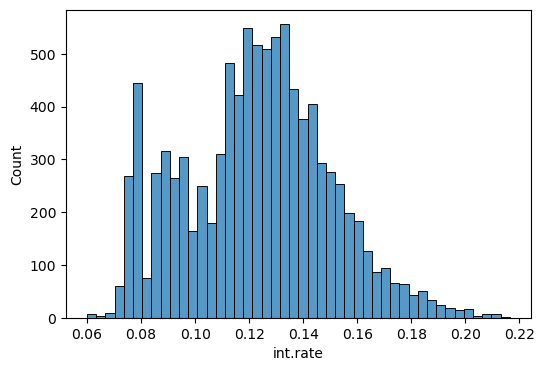

In [18]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'int.rate')
plt.show()

- int.rate is a Numerical and Continuous feature having distribution close to Normal.
- Ttansformations: Scaling.

In [26]:
intrate_pipeline = Pipeline([
    ('scaling', StandardScaler())
])

##### 4) installment:

In [28]:
df['installment']

0       829.10
1       228.22
2       366.86
3       162.34
4       102.92
         ...  
9573    344.76
9574    257.70
9575     97.81
9576    351.58
9577    853.43
Name: installment, Length: 9578, dtype: float64

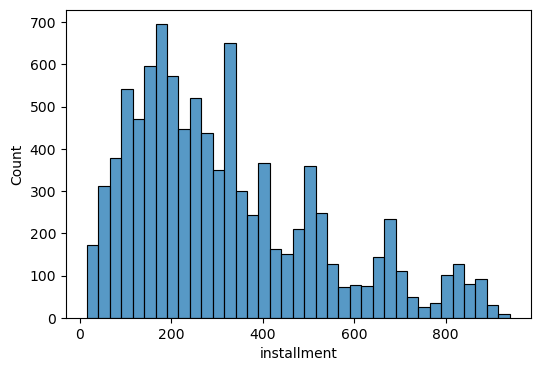

In [29]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'installment')
plt.show()

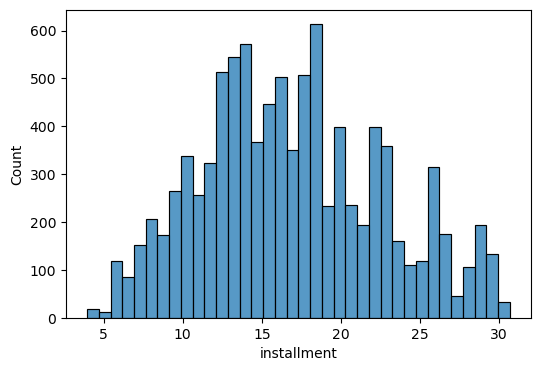

In [36]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['installment'].apply(np.sqrt))
plt.show()

- installment is a Numeric and continuous feature with right tailed distribution.
- Transformation: Square Root Transformation, Scaling.

In [38]:
installment_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

##### 5) log.annual.inc:

In [40]:
df['log.annual.inc']

0       11.350407
1       11.082143
2       10.373491
3       11.350407
4       11.299732
          ...    
9573    12.180755
9574    11.141862
9575    10.596635
9576    10.819778
9577    11.264464
Name: log.annual.inc, Length: 9578, dtype: float64

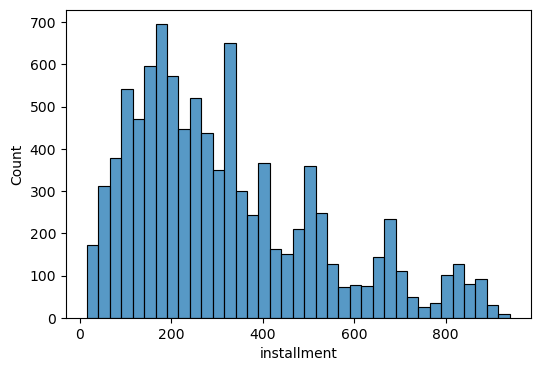

In [41]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'installment')
plt.show()

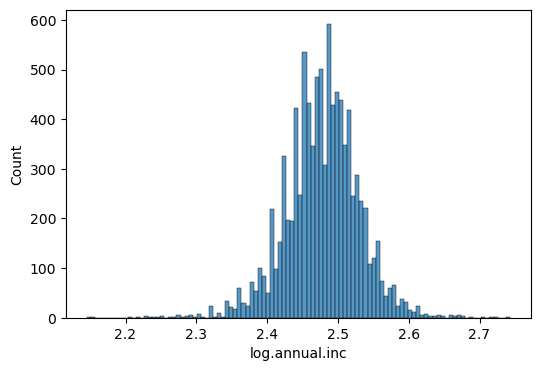

In [47]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['log.annual.inc'].apply(np.log1p))
plt.show()

- log.annual.inc is a Numeric Continuous feature with a sligh right tailed distribution.
- Transformations: Log Transformation, Scaling.

In [48]:
annualinc_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])